In [1]:
# Anna code modified to run (imported modules and functions)

# import modules ===================================================================================================
import numpy as np, matplotlib.pyplot as plt, pandas as pd, pynbody, os
import scipy, timeit
import matplotlib.colors as colors
plt.rcParams.update(plt.rcParamsDefault)

# This must be done BEFORE importing tangos
# Set the path to your TANGOS database
path = '/home/amolle/Marvel_recent.db'
os.environ['TANGOS_DB_CONNECTION'] = path

import tangos 

# pick sim
sims = tangos.all_simulations()
print("simulations found:", sims)

# FUNCS ===============================================================================================================
def fit_cEinasto_prof(log_r, log_rho0, log_rs, log_rc):
    """
    core-Einasto profile in log10 space 
    inputs(in log base 10): radius, rho0, rscale, rcore
    return(in log base 10 array): density 
    """
    alpha_ep = 0.16
    rho0 = 10**log_rho0
    rs = 10**log_rs
    r = 10**log_r
    rc = 10**log_rc
    return np.log10(rho0 * np.exp((-2/alpha_ep) * (((r + rc)/rs)**(alpha_ep) - 1)))

def cEinasto_profile(r, rho0, rs, rc):
    """
    core-Einasto profile in linear space
    """
    alpha_ep = 0.16
    return rho0 * np.exp((-2/alpha_ep) * (((r + rc)/rs)**(alpha_ep) - 1))
    
def cEinasto_logslope(r, rs, rc):
    
    alpha_ep = 0.16
    return -2 * (r/rs)**alpha_ep * (1 + (rc/r))**(alpha_ep-1)


def curvefits(model, output, halo, baryon, fit_type, bounds, p0,family, r, den):
    lim_realden = den > 0
    log_r = np.log10(r[lim_realden])
    log_den = np.log10(den[lim_realden])

    if(len(bounds) > 1):
        fit, cov = scipy.optimize.curve_fit(fit_cEinasto_prof, log_r, log_den, p0=p0, bounds=bounds, maxfev=10000)
    else:
        fit, cov = scipy.optimize.curve_fit(fit_cEinasto_prof, log_r, log_den)
    log_den_fit = fit_cEinasto_prof(log_r, fit[0], fit[1], fit[2])
    residue_den = (log_den_fit-log_den)**2
    Q = np.sqrt(np.mean(residue_den))
    return fit, Q, residue_den
    
def optim_fit(model, fit_type, output, rs_bounds, baryon, family, ID, r, den, rvir, sim):

    r = np.array(r)
    den = np.array(den)
    
    outfn = f"cvir_outputs/logs_output_sim_{sim}_ID_{ID}.txt"
    outfile = open(outfn, 'w')
    outfile.write('Q min_rs rhos rs[kpc] rc[kpc] rvir[kpc]\n')

    # resolution limits 
    mask = (r >= 0.25) & (r <= rvir)
    r = r[mask]
    den = den[mask]

    # limits for rho0
    rho0_l = 1e4
    rho0_h = 1e10
    
    # limits for rscale + rcore
    rs_h = rvir
    rc_l = 1e-8
    rc_h = rvir/25

    for rs_l in rs_bounds:
        if fit_type == 'cEinasto':
            bounds    = ([np.log10(rho0_l), np.log10(rs_l), np.log10(rc_l)],
                         [np.log10(rho0_h), np.log10(rs_h), np.log10(rc_h)])
            p0 = (np.log10(1e6), np.log10(rvir/2), np.log10(rvir/25))

            log_fitparams, Q, residue_den= curvefits(model, output, halo, baryon, fit_type, bounds, p0, family, r, den)
            fitparams = 10**log_fitparams
            rhos = fitparams[0]
            rs = fitparams[1]
            rc = fitparams[2]
            
            rc = max(rc, rc_l)
            #print(f'halo:{ID} bounds: [{mrs},{r_h}] rs: {rs:.3f} rc: {rc:.3f}  Q: {Q:.3f} cvir: {(rvir/rs):.3f}\n\n')
        outfile.write('%.3f %.3f %.3f %.3f %.3f %.3f\n' %(Q, rs_l, rhos, rs, rc, rvir))
    outfile.close()

    #print(f'halo:{ID} rhos = {rhos:.3e} rs = {rs:.3f} rs_l = {rs_l:.3f} rvir = {rvir:.3f} Q = {Q:.3f}')
    return Q


/home/amolle/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


simulations found: [<Simulation("cptmarvel.cosmo25cmb.4096g5HbwK1BH")>, <Simulation("elektra.cosmo25cmb.4096g5HbwK1BH")>, <Simulation("rogue.cosmo25cmb.4096g5HbwK1BH")>, <Simulation("storm.cosmo25cmb.4096g5HbwK1BH")>]


length sim = 555
ID:241136 Mvir = 1.553e+10
rc_i:0.256 rs_i: 4.48
ID:241137 Mvir = 9.882e+09
rc_i:0.372 rs_i: 4.925
ID:241138 Mvir = 8.747e+09
rc_i:0.193 rs_i: 4.657
ID:241139 Mvir = 7.502e+09
rc_i:0.756 rs_i: 2.381
ID:241140 Mvir = 6.584e+09
rc_i:0.075 rs_i: 5.074
ID:241141 Mvir = 5.101e+09
rc_i:0.0 rs_i: 3.963
ID:241142 Mvir = 3.484e+09
rc_i:0.152 rs_i: 1.954
ID:241143 Mvir = 2.247e+09
rc_i:0.0 rs_i: 4.29
ID:241144 Mvir = 1.804e+09
rc_i:0.111 rs_i: 1.855
ID:241145 Mvir = 1.559e+09
rc_i:0.0 rs_i: 3.114
ID:241146 Mvir = 6.242e+08
rc_i:0.0 rs_i: 2.262
ID:241147 Mvir = 4.081e+08
rc_i:0.0 rs_i: 0.958
ID:241148 Mvir = 3.876e+08
rc_i:0.089 rs_i: 0.537
ID:241149 Mvir = 3.755e+08
rc_i:0.0 rs_i: 0.897
  current ID: 241150
ID:241150 Mvir = 3.652e+08
rc_i:0.174 rs_i: 0.423
ID:241151 Mvir = 3.209e+08
rc_i:0.116 rs_i: 0.523
ID:241152 Mvir = 3.173e+08
rc_i:0.293 rs_i: 0.454
ID:241153 Mvir = 3.071e+08
rc_i:0.076 rs_i: 0.588
ID:241154 Mvir = 3.011e+08
rc_i:0.0 rs_i: 1.369
ID:241155 Mvir = 2.936e+08
r

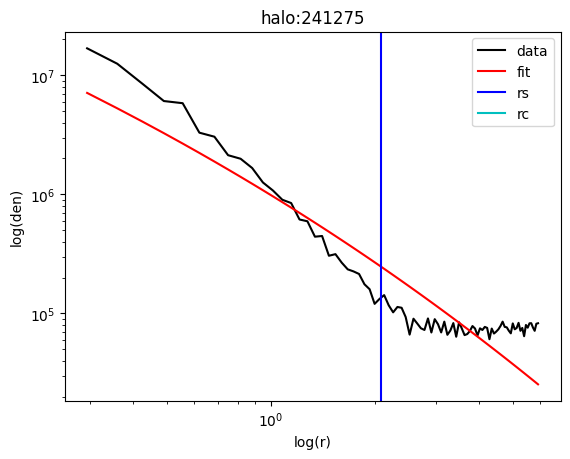

rc_i:0.0 rs_i: 2.083
ID:241276 Mvir = 2.563e+07
rc_i:0.0 rs_i: 0.321
ID:241277 Mvir = 2.557e+07
rc_i:0.0 rs_i: 0.25
ID:241278 Mvir = 2.552e+07
rc_i:0.0 rs_i: 0.25
ID:241279 Mvir = 2.534e+07
rc_i:0.0 rs_i: 0.25
ID:241280 Mvir = 2.528e+07
rc_i:0.0 rs_i: 0.436
ID:241281 Mvir = 2.517e+07
rc_i:0.0 rs_i: 0.322
ID:241282 Mvir = 2.506e+07
rc_i:0.012 rs_i: 0.336
ID:241283 Mvir = 2.498e+07
rc_i:0.0 rs_i: 0.25
ID:241284 Mvir = 2.485e+07
rc_i:0.0 rs_i: 0.25
ID:241285 Mvir = 2.450e+07
rc_i:0.01 rs_i: 0.349
ID:241286 Mvir = 2.433e+07
rc_i:0.0 rs_i: 0.25
ID:241287 Mvir = 2.430e+07
rc_i:0.004 rs_i: 0.313
ID:241288 Mvir = 2.421e+07
rc_i:0.0 rs_i: 1.455
ID:241289 Mvir = 2.418e+07
rc_i:0.0 rs_i: 0.321
ID:241290 Mvir = 2.409e+07
rc_i:0.0 rs_i: 0.651
ID:241291 Mvir = 2.381e+07
rc_i:0.054 rs_i: 0.338
ID:241292 Mvir = 2.359e+07
rc_i:0.0 rs_i: 0.332
ID:241293 Mvir = 2.348e+07
rc_i:0.0 rs_i: 0.409
ID:241294 Mvir = 2.323e+07
rc_i:0.0 rs_i: 0.274
ID:241295 Mvir = 2.308e+07
rc_i:0.0 rs_i: 0.25
ID:241296 Mvir = 2.

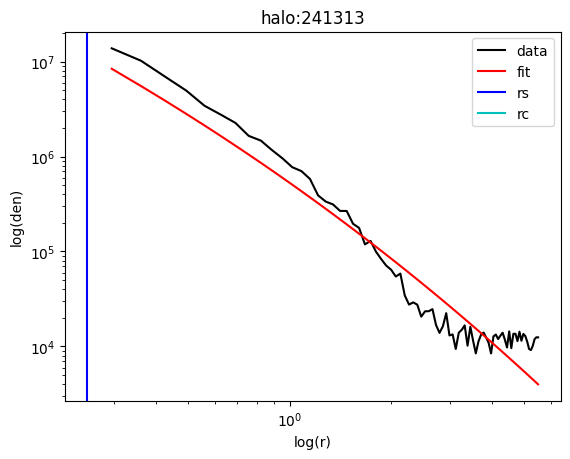

rc_i:0.0 rs_i: 0.25
ID:241314 Mvir = 2.024e+07
rc_i:0.0 rs_i: 0.29
ID:241315 Mvir = 2.024e+07
rc_i:0.0 rs_i: 0.25
ID:241316 Mvir = 1.998e+07
rc_i:0.0 rs_i: 0.284
ID:241317 Mvir = 1.970e+07
rc_i:0.0 rs_i: 0.273
ID:241318 Mvir = 1.960e+07
rc_i:0.0 rs_i: 0.25
ID:241319 Mvir = 1.958e+07
rc_i:0.0 rs_i: 0.391
ID:241320 Mvir = 1.952e+07
rc_i:0.0 rs_i: 0.25
ID:241321 Mvir = 1.946e+07
rc_i:0.0 rs_i: 0.605
ID:241322 Mvir = 1.937e+07
rc_i:0.0 rs_i: 1.588
ID:241323 Mvir = 1.936e+07
rc_i:0.0 rs_i: 0.25
ID:241324 Mvir = 1.936e+07
rc_i:0.0 rs_i: 0.788
  current ID: 241325
ID:241325 Mvir = 1.934e+07
rc_i:0.0 rs_i: 0.254
ID:241326 Mvir = 1.904e+07
rc_i:0.0 rs_i: 0.587
ID:241327 Mvir = 1.900e+07
rc_i:0.0 rs_i: 0.399
ID:241328 Mvir = 1.899e+07
rc_i:0.0 rs_i: 0.488
ID:241329 Mvir = 1.850e+07
rc_i:0.101 rs_i: 0.25
ID:241330 Mvir = 1.840e+07
rc_i:0.0 rs_i: 0.25
ID:241331 Mvir = 1.836e+07
rc_i:0.0 rs_i: 0.867
ID:241332 Mvir = 1.820e+07
rc_i:0.0 rs_i: 0.654
ID:241333 Mvir = 1.782e+07
rc_i:0.0 rs_i: 0.296
ID:2

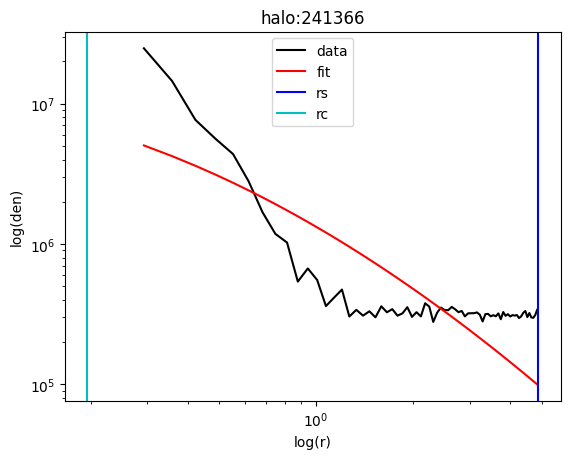

rc_i:0.195 rs_i: 4.875
ID:241367 Mvir = 1.516e+07
rc_i:0.0 rs_i: 0.296
ID:241368 Mvir = 1.508e+07


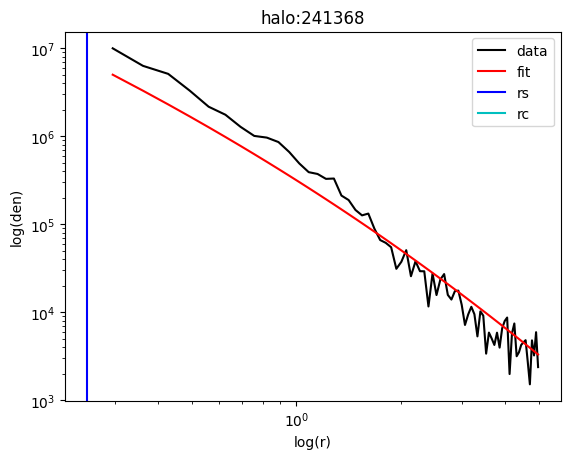

rc_i:0.0 rs_i: 0.25
ID:241369 Mvir = 1.499e+07
rc_i:0.0 rs_i: 0.25
ID:241370 Mvir = 1.492e+07
rc_i:0.0 rs_i: 0.417
ID:241371 Mvir = 1.487e+07
rc_i:0.0 rs_i: 0.34
ID:241372 Mvir = 1.484e+07
rc_i:0.0 rs_i: 0.25
ID:241373 Mvir = 1.482e+07
rc_i:0.0 rs_i: 0.338
ID:241374 Mvir = 1.467e+07
rc_i:0.0 rs_i: 0.25
  current ID: 241375
ID:241375 Mvir = 1.465e+07
rc_i:0.064 rs_i: 0.25
ID:241376 Mvir = 1.456e+07
rc_i:0.0 rs_i: 0.586
ID:241377 Mvir = 1.439e+07
rc_i:0.058 rs_i: 0.385
ID:241378 Mvir = 1.437e+07
rc_i:0.0 rs_i: 0.25
ID:241379 Mvir = 1.437e+07
rc_i:0.0 rs_i: 0.642
ID:241380 Mvir = 1.432e+07
rc_i:0.052 rs_i: 0.25
ID:241381 Mvir = 1.431e+07
rc_i:0.017 rs_i: 0.272
ID:241382 Mvir = 1.417e+07
rc_i:0.025 rs_i: 0.257
ID:241383 Mvir = 1.416e+07
rc_i:0.0 rs_i: 0.25
ID:241384 Mvir = 1.413e+07
rc_i:0.0 rs_i: 0.406
ID:241385 Mvir = 1.399e+07
rc_i:0.0 rs_i: 0.259
ID:241386 Mvir = 1.383e+07
rc_i:0.0 rs_i: 0.25
ID:241387 Mvir = 1.382e+07
rc_i:0.0 rs_i: 0.25
ID:241388 Mvir = 1.375e+07
rc_i:0.0 rs_i: 0.25


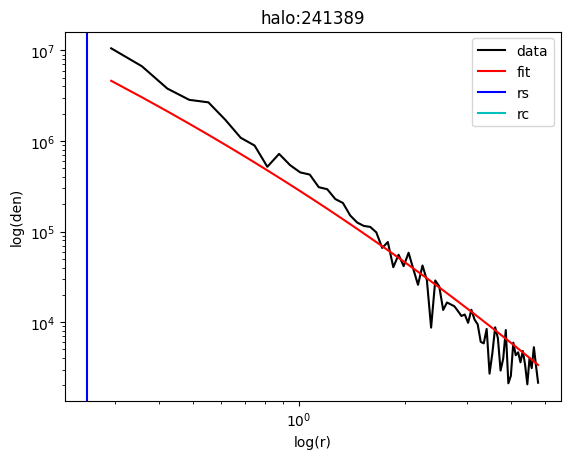

rc_i:0.0 rs_i: 0.25
ID:241390 Mvir = 1.367e+07
rc_i:0.0 rs_i: 0.25
ID:241391 Mvir = 1.355e+07
rc_i:0.093 rs_i: 0.25
ID:241392 Mvir = 1.349e+07
rc_i:0.024 rs_i: 0.25
ID:241393 Mvir = 1.344e+07
rc_i:0.0 rs_i: 0.276
ID:241394 Mvir = 1.341e+07
rc_i:0.0 rs_i: 0.313
ID:241395 Mvir = 1.335e+07
rc_i:0.0 rs_i: 0.927
ID:241396 Mvir = 1.329e+07
rc_i:0.0 rs_i: 0.25
ID:241397 Mvir = 1.319e+07


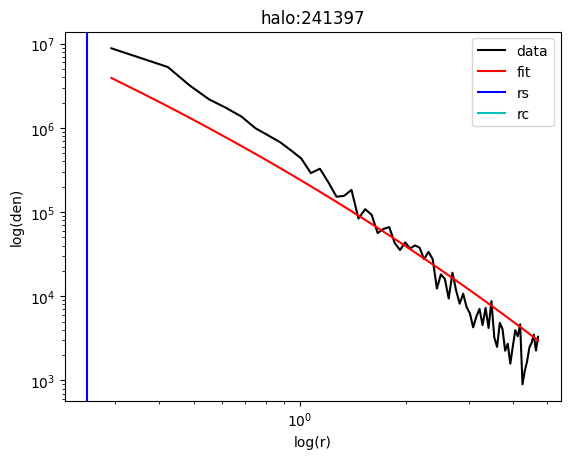

rc_i:0.0 rs_i: 0.25
ID:241398 Mvir = 1.318e+07
rc_i:0.0 rs_i: 0.25
ID:241399 Mvir = 1.317e+07
rc_i:0.0 rs_i: 0.25
  current ID: 241400
ID:241400 Mvir = 1.314e+07
rc_i:0.0 rs_i: 0.309
ID:241401 Mvir = 1.298e+07
rc_i:0.0 rs_i: 0.261
ID:241402 Mvir = 1.294e+07
rc_i:0.0 rs_i: 0.25
ID:241403 Mvir = 1.287e+07
rc_i:0.0 rs_i: 0.379
ID:241404 Mvir = 1.278e+07
rc_i:0.0 rs_i: 0.25
ID:241405 Mvir = 1.275e+07
rc_i:0.0 rs_i: 0.25
ID:241406 Mvir = 1.275e+07
rc_i:0.0 rs_i: 0.25
ID:241407 Mvir = 1.273e+07
rc_i:0.0 rs_i: 0.25
ID:241408 Mvir = 1.272e+07
rc_i:0.0 rs_i: 0.25
ID:241409 Mvir = 1.268e+07
rc_i:0.0 rs_i: 0.25
ID:241410 Mvir = 1.257e+07


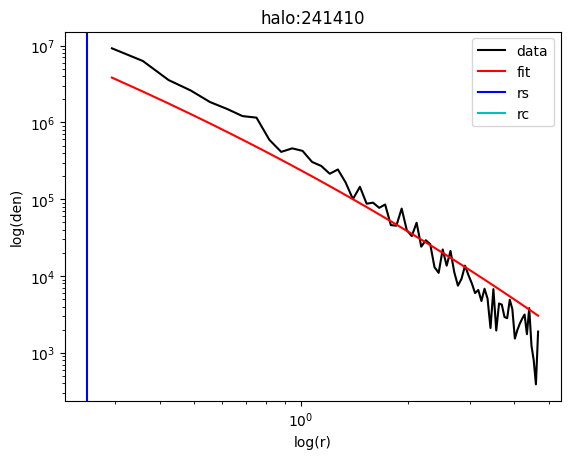

rc_i:0.0 rs_i: 0.25
ID:241411 Mvir = 1.256e+07
rc_i:0.0 rs_i: 0.25
ID:241412 Mvir = 1.236e+07
rc_i:0.0 rs_i: 0.617
ID:241413 Mvir = 1.236e+07
rc_i:0.0 rs_i: 0.582
ID:241414 Mvir = 1.232e+07
rc_i:0.0 rs_i: 0.309
ID:241415 Mvir = 1.232e+07
rc_i:0.0 rs_i: 0.333
ID:241416 Mvir = 1.223e+07
rc_i:0.0 rs_i: 0.25
ID:241417 Mvir = 1.218e+07
rc_i:0.0 rs_i: 0.276
ID:241418 Mvir = 1.218e+07
rc_i:0.0 rs_i: 0.25
ID:241419 Mvir = 1.218e+07
rc_i:0.0 rs_i: 0.25
ID:241420 Mvir = 1.217e+07
rc_i:0.0 rs_i: 0.344
ID:241421 Mvir = 1.214e+07
rc_i:0.0 rs_i: 0.449
ID:241422 Mvir = 1.213e+07
rc_i:0.0 rs_i: 0.25
ID:241423 Mvir = 1.212e+07
rc_i:0.0 rs_i: 1.148
ID:241424 Mvir = 1.206e+07
rc_i:0.0 rs_i: 0.379
  current ID: 241425
ID:241425 Mvir = 1.204e+07
rc_i:0.0 rs_i: 0.561
ID:241426 Mvir = 1.201e+07
rc_i:0.0 rs_i: 0.25
ID:241427 Mvir = 1.201e+07
rc_i:0.0 rs_i: 0.25
ID:241428 Mvir = 1.198e+07
rc_i:0.0 rs_i: 0.25
ID:241429 Mvir = 1.193e+07
rc_i:0.0 rs_i: 0.25
ID:241430 Mvir = 1.192e+07
rc_i:0.0 rs_i: 1.19
ID:241431

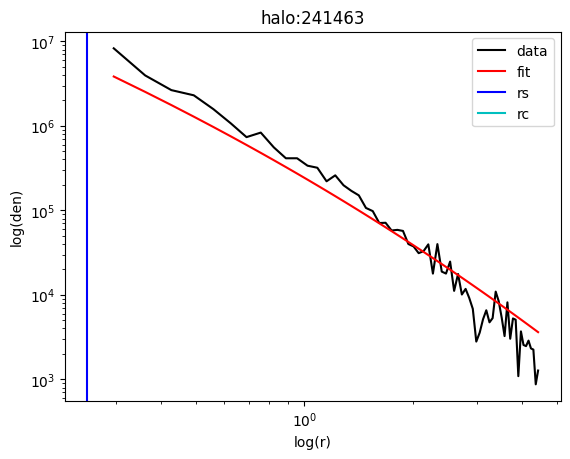

rc_i:0.0 rs_i: 0.25
ID:241464 Mvir = 1.084e+07
rc_i:0.0 rs_i: 0.25
ID:241465 Mvir = 1.081e+07
rc_i:0.0 rs_i: 0.38
ID:241466 Mvir = 1.080e+07
rc_i:0.0 rs_i: 0.391
ID:241467 Mvir = 1.078e+07


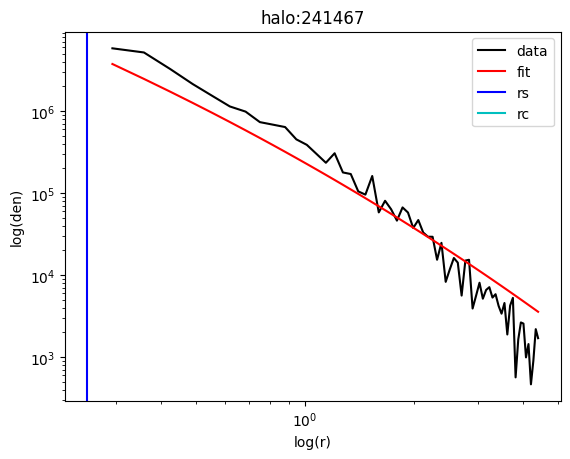

rc_i:0.0 rs_i: 0.25
ID:241468 Mvir = 1.076e+07
rc_i:0.0 rs_i: 0.25
ID:241469 Mvir = 1.074e+07
rc_i:0.0 rs_i: 0.25
ID:241470 Mvir = 1.065e+07
rc_i:0.0 rs_i: 0.25
ID:241471 Mvir = 1.064e+07
rc_i:0.0 rs_i: 0.25
ID:241472 Mvir = 1.064e+07
rc_i:0.0 rs_i: 0.425
ID:241473 Mvir = 1.059e+07
rc_i:0.0 rs_i: 0.25
ID:241474 Mvir = 1.059e+07


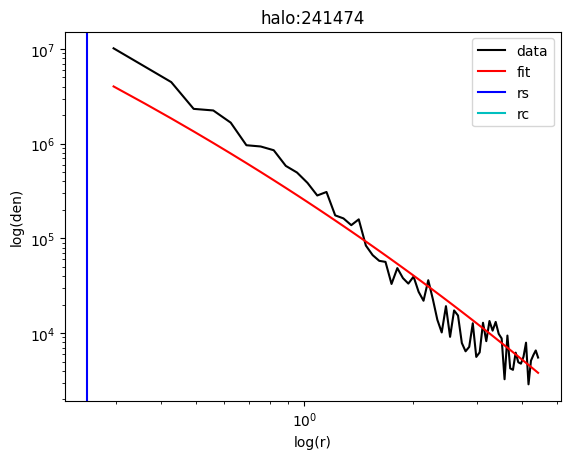

rc_i:0.0 rs_i: 0.25
  current ID: 241475
ID:241475 Mvir = 1.052e+07
rc_i:0.0 rs_i: 0.25
ID:241476 Mvir = 1.047e+07
rc_i:0.0 rs_i: 0.314
ID:241477 Mvir = 1.047e+07
rc_i:0.0 rs_i: 0.25
ID:241478 Mvir = 1.042e+07
rc_i:0.0 rs_i: 0.25
ID:241479 Mvir = 1.041e+07
rc_i:0.0 rs_i: 0.25
ID:241480 Mvir = 1.040e+07
rc_i:0.0 rs_i: 0.25
ID:241481 Mvir = 1.036e+07
rc_i:0.0 rs_i: 0.25
ID:241482 Mvir = 1.028e+07
rc_i:0.0 rs_i: 0.25
ID:241483 Mvir = 1.026e+07
rc_i:0.0 rs_i: 0.383
ID:241484 Mvir = 1.022e+07


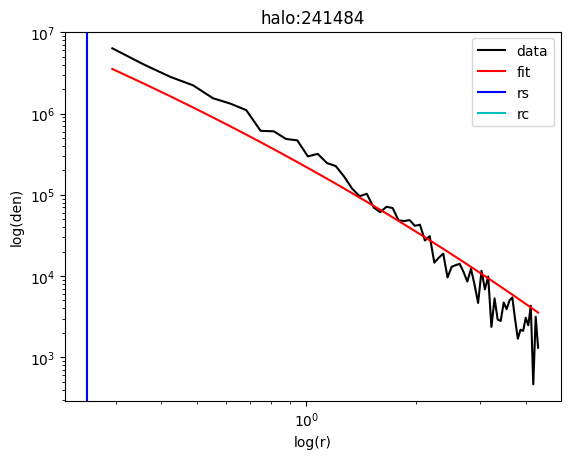

rc_i:0.0 rs_i: 0.25
ID:241485 Mvir = 1.020e+07
rc_i:0.0 rs_i: 0.25
ID:241486 Mvir = 1.018e+07
rc_i:0.0 rs_i: 0.25
ID:241487 Mvir = 1.012e+07
rc_i:0.0 rs_i: 0.25
ID:241488 Mvir = 1.010e+07
rc_i:0.0 rs_i: 0.426
ID:241489 Mvir = 1.009e+07
rc_i:0.0 rs_i: 0.25
ID:241490 Mvir = 1.007e+07
rc_i:0.0 rs_i: 0.328
ID:241491 Mvir = 1.002e+07
rc_i:0.0 rs_i: 0.35
ID:241492 Mvir = 1.000e+07
rc_i:0.0 rs_i: 0.25
ID:241493 Mvir = 9.998e+06
rc_i:0.0 rs_i: 0.422
ID:241494 Mvir = 9.945e+06
rc_i:0.0 rs_i: 0.25
ID:241495 Mvir = 9.931e+06
rc_i:0.0 rs_i: 0.25
ID:241496 Mvir = 9.911e+06
rc_i:0.0 rs_i: 2.577
ID:241497 Mvir = 9.751e+06
rc_i:0.0 rs_i: 0.25
ID:241498 Mvir = 9.745e+06
rc_i:0.0 rs_i: 0.25
ID:241499 Mvir = 9.731e+06
rc_i:0.0 rs_i: 0.406
  current ID: 241500
ID:241500 Mvir = 9.718e+06
rc_i:0.0 rs_i: 1.412
ID:241501 Mvir = 9.665e+06
rc_i:0.0 rs_i: 0.25
ID:241502 Mvir = 9.592e+06
rc_i:0.0 rs_i: 0.25
ID:241503 Mvir = 9.532e+06
rc_i:0.0 rs_i: 0.871
ID:241504 Mvir = 9.492e+06
rc_i:0.0 rs_i: 0.29
ID:241505 Mv

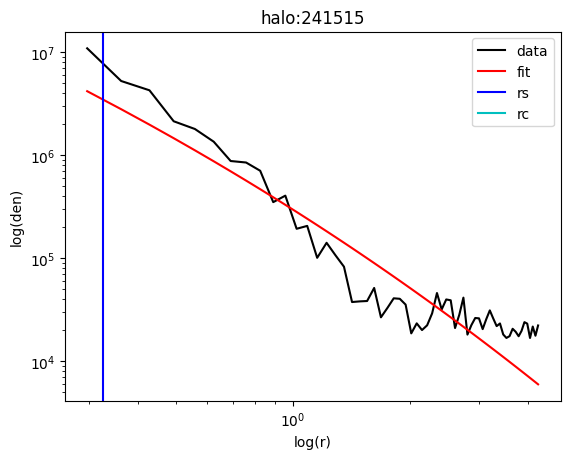

rc_i:0.0 rs_i: 0.325
ID:241516 Mvir = 9.252e+06


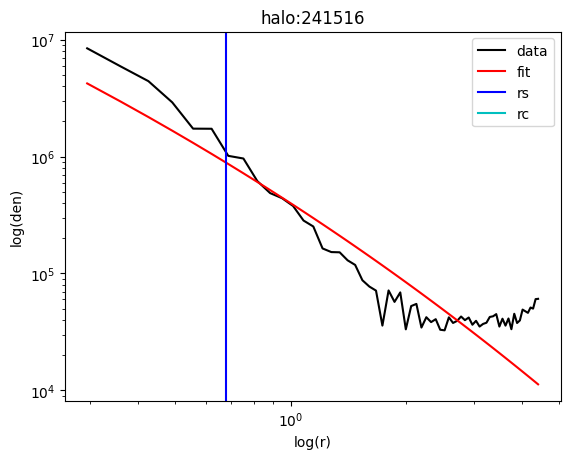

rc_i:0.0 rs_i: 0.679
ID:241517 Mvir = 9.225e+06
rc_i:0.0 rs_i: 0.25
ID:241518 Mvir = 9.212e+06
rc_i:0.0 rs_i: 0.296
ID:241519 Mvir = 9.199e+06
rc_i:0.0 rs_i: 0.399
ID:241520 Mvir = 9.192e+06
rc_i:0.0 rs_i: 0.25
ID:241521 Mvir = 9.172e+06
rc_i:0.0 rs_i: 0.25
ID:241522 Mvir = 9.139e+06
rc_i:0.0 rs_i: 0.647
ID:241523 Mvir = 9.132e+06
rc_i:0.0 rs_i: 0.396
ID:241524 Mvir = 9.099e+06
rc_i:0.0 rs_i: 0.263
  current ID: 241525
ID:241525 Mvir = 9.045e+06
rc_i:0.0 rs_i: 4.768
ID:241526 Mvir = 9.005e+06
rc_i:0.0 rs_i: 0.326
ID:241527 Mvir = 8.999e+06
rc_i:0.0 rs_i: 0.277
ID:241528 Mvir = 8.979e+06
rc_i:0.0 rs_i: 0.25
ID:241529 Mvir = 8.959e+06
rc_i:0.0 rs_i: 0.25
ID:241530 Mvir = 8.945e+06
rc_i:0.0 rs_i: 0.25
ID:241531 Mvir = 8.945e+06
rc_i:0.0 rs_i: 0.25
ID:241532 Mvir = 8.939e+06
rc_i:0.0 rs_i: 0.25
ID:241533 Mvir = 8.932e+06


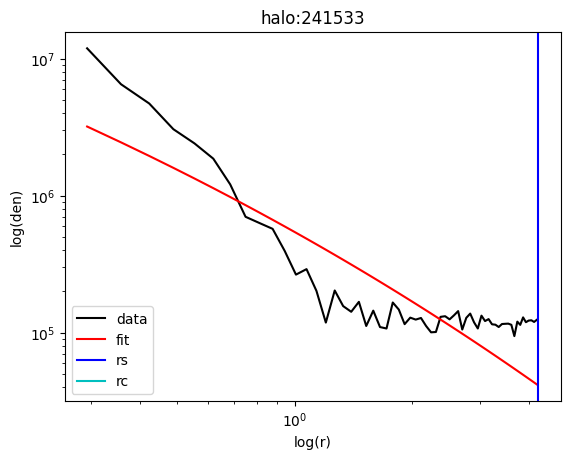

rc_i:0.0 rs_i: 4.229
ID:241534 Mvir = 8.919e+06


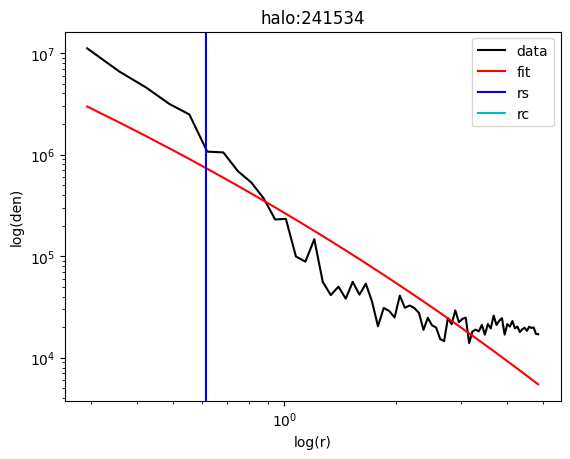

rc_i:0.0 rs_i: 0.613
ID:241535 Mvir = 8.912e+06
rc_i:0.0 rs_i: 0.325
ID:241536 Mvir = 8.899e+06
rc_i:0.0 rs_i: 0.25
ID:241537 Mvir = 8.899e+06
rc_i:0.0 rs_i: 0.25
ID:241538 Mvir = 8.879e+06
rc_i:0.0 rs_i: 0.25
ID:241539 Mvir = 8.839e+06


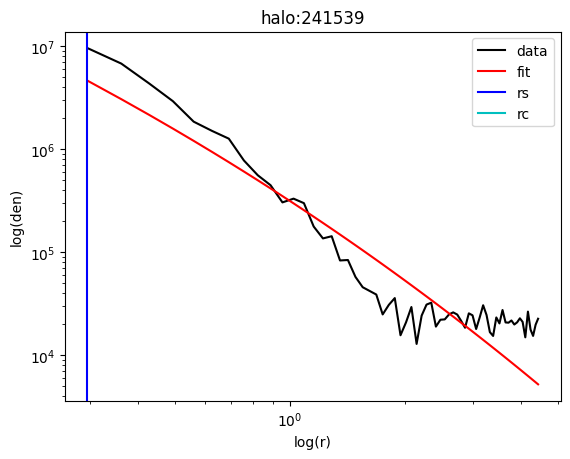

rc_i:0.0 rs_i: 0.295
ID:241540 Mvir = 8.832e+06
rc_i:0.0 rs_i: 0.3
ID:241541 Mvir = 8.806e+06
rc_i:0.0 rs_i: 0.25
ID:241542 Mvir = 8.806e+06
rc_i:0.0 rs_i: 0.25
ID:241543 Mvir = 8.786e+06


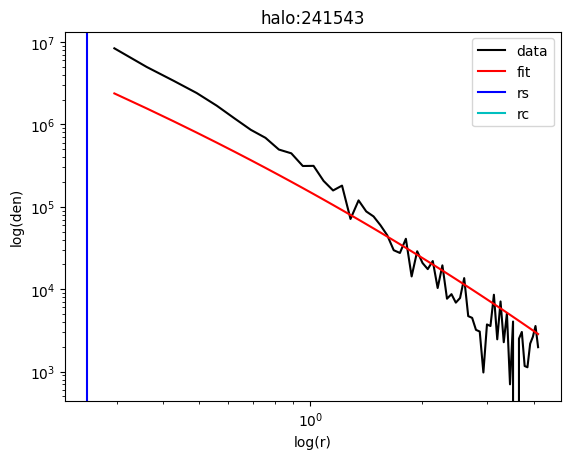

rc_i:0.0 rs_i: 0.25
ID:241544 Mvir = 8.772e+06
rc_i:0.0 rs_i: 0.25
ID:241545 Mvir = 8.759e+06
rc_i:0.0 rs_i: 0.25
ID:241546 Mvir = 8.746e+06
rc_i:0.0 rs_i: 0.362
ID:241547 Mvir = 8.739e+06
rc_i:0.0 rs_i: 0.25
ID:241548 Mvir = 8.739e+06
rc_i:0.0 rs_i: 0.25
ID:241549 Mvir = 8.712e+06
rc_i:0.0 rs_i: 0.25
  current ID: 241550
ID:241550 Mvir = 8.706e+06
rc_i:0.0 rs_i: 0.292
ID:241551 Mvir = 9.215e+06
rc_i:0.0 rs_i: 0.25
ID:241552 Mvir = 8.699e+06
rc_i:0.0 rs_i: 0.25
ID:241553 Mvir = 8.672e+06


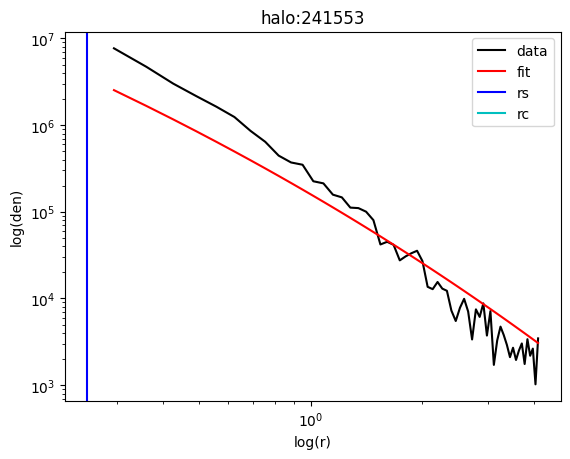

rc_i:0.0 rs_i: 0.25
ID:241554 Mvir = 8.606e+06
rc_i:0.0 rs_i: 0.25
ID:241555 Mvir = 8.586e+06
rc_i:0.0 rs_i: 0.277
ID:241556 Mvir = 8.559e+06
rc_i:0.0 rs_i: 1.058
ID:241557 Mvir = 8.546e+06


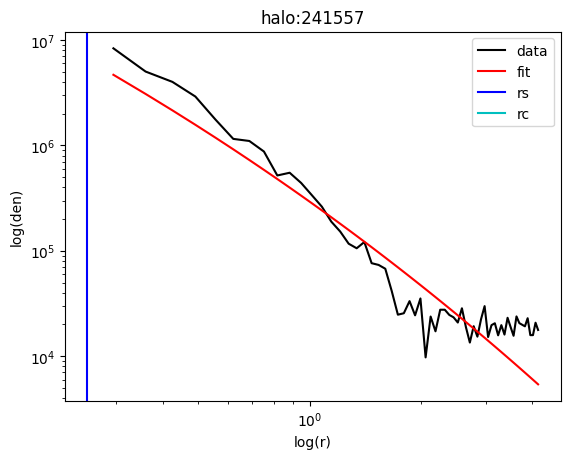

rc_i:0.0 rs_i: 0.25
ID:241558 Mvir = 8.539e+06
rc_i:0.0 rs_i: 0.25
ID:241559 Mvir = 8.519e+06
rc_i:0.0 rs_i: 0.25
ID:241560 Mvir = 8.506e+06
rc_i:0.0 rs_i: 0.25
ID:241561 Mvir = 8.493e+06
rc_i:0.0 rs_i: 0.262
ID:241562 Mvir = 8.479e+06
rc_i:0.0 rs_i: 0.25
ID:241563 Mvir = 8.479e+06
rc_i:0.0 rs_i: 0.818
ID:241564 Mvir = 8.479e+06
rc_i:0.0 rs_i: 0.26
ID:241565 Mvir = 8.479e+06
rc_i:0.0 rs_i: 0.389
ID:241566 Mvir = 8.479e+06
rc_i:0.0 rs_i: 0.25
ID:241567 Mvir = 8.446e+06
rc_i:0.0 rs_i: 0.25
ID:241568 Mvir = 8.426e+06
rc_i:0.0 rs_i: 0.25
ID:241569 Mvir = 8.413e+06
rc_i:0.0 rs_i: 0.25
ID:241570 Mvir = 8.353e+06
rc_i:0.0 rs_i: 0.25
ID:241571 Mvir = 8.319e+06
rc_i:0.0 rs_i: 0.25
ID:241572 Mvir = 8.306e+06
rc_i:0.0 rs_i: 0.25
ID:241573 Mvir = 8.286e+06
rc_i:0.0 rs_i: 0.25
ID:241574 Mvir = 8.279e+06
rc_i:0.0 rs_i: 0.25
  current ID: 241575
ID:241575 Mvir = 8.266e+06
rc_i:0.0 rs_i: 0.305
ID:241576 Mvir = 8.259e+06
rc_i:0.0 rs_i: 0.25
ID:241577 Mvir = 8.239e+06
rc_i:0.0 rs_i: 0.25
ID:241578 Mvir 

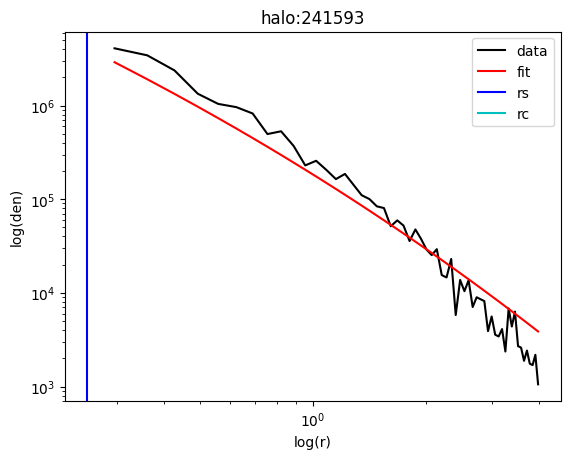

rc_i:0.0 rs_i: 0.25
ID:241594 Mvir = 7.833e+06
rc_i:0.0 rs_i: 0.362
ID:241595 Mvir = 7.833e+06
rc_i:0.0 rs_i: 0.461
ID:241596 Mvir = 7.826e+06
rc_i:0.0 rs_i: 0.25
ID:241597 Mvir = 7.826e+06
rc_i:0.0 rs_i: 0.379
ID:241598 Mvir = 7.786e+06
rc_i:0.0 rs_i: 0.325
ID:241599 Mvir = 7.780e+06
rc_i:0.0 rs_i: 0.25
  current ID: 241600
ID:241600 Mvir = 7.773e+06
rc_i:0.0 rs_i: 0.25
ID:241601 Mvir = 7.766e+06


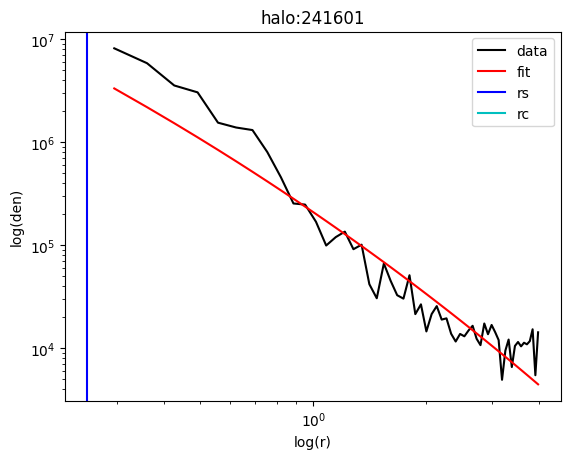

rc_i:0.0 rs_i: 0.25
ID:241602 Mvir = 7.766e+06
rc_i:0.0 rs_i: 0.25
ID:241603 Mvir = 7.747e+06


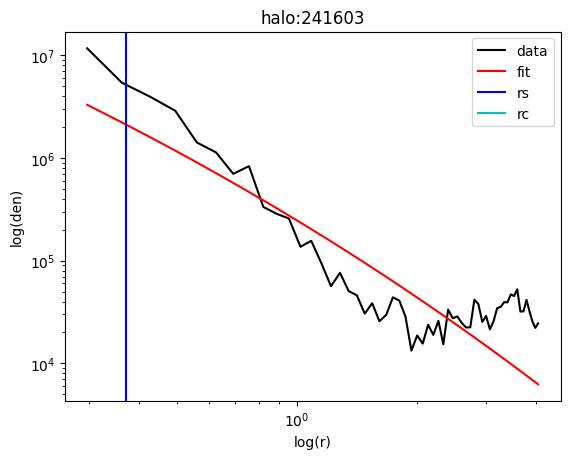

rc_i:0.0 rs_i: 0.37
ID:241604 Mvir = 7.713e+06
rc_i:0.0 rs_i: 0.46
ID:241605 Mvir = 7.673e+06
rc_i:0.0 rs_i: 0.25
ID:241606 Mvir = 7.660e+06
rc_i:0.0 rs_i: 0.564
ID:241607 Mvir = 7.640e+06
rc_i:0.0 rs_i: 0.25
ID:241608 Mvir = 7.640e+06


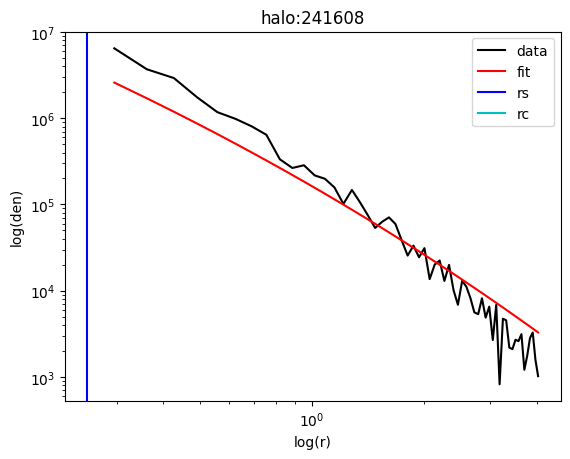

rc_i:0.0 rs_i: 0.25
ID:241609 Mvir = 7.627e+06
rc_i:0.0 rs_i: 0.622
ID:241610 Mvir = 7.627e+06
rc_i:0.0 rs_i: 0.276
ID:241611 Mvir = 7.627e+06
rc_i:0.0 rs_i: 0.338
ID:241612 Mvir = 7.620e+06
rc_i:0.0 rs_i: 0.25
ID:241613 Mvir = 7.607e+06
rc_i:0.0 rs_i: 0.25
ID:241614 Mvir = 7.593e+06


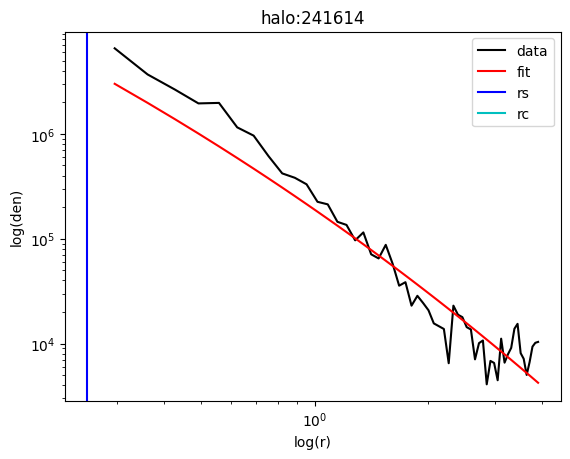

rc_i:0.0 rs_i: 0.25
ID:241615 Mvir = 7.587e+06


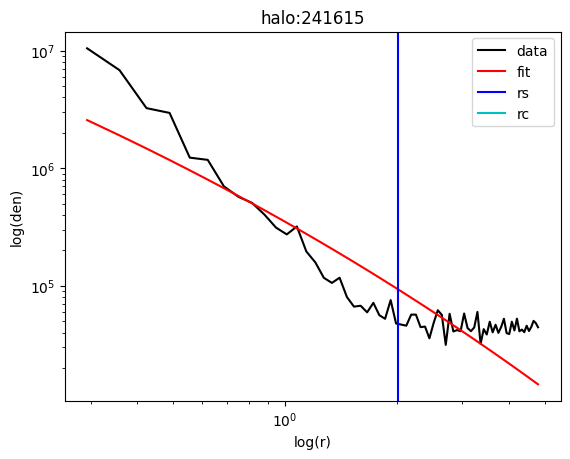

rc_i:0.0 rs_i: 2.018
ID:241616 Mvir = 7.560e+06


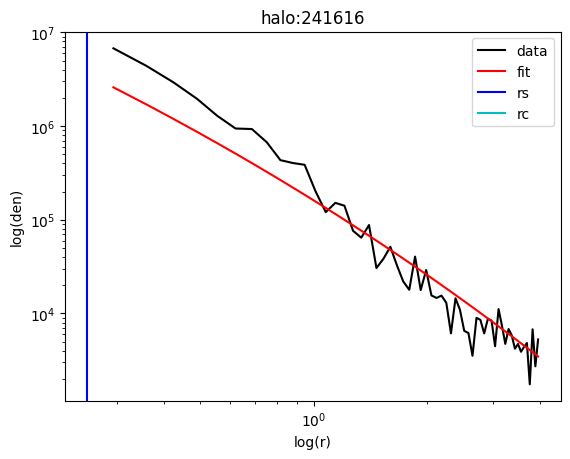

rc_i:0.0 rs_i: 0.25
ID:241617 Mvir = 7.553e+06
rc_i:0.0 rs_i: 0.25
ID:241618 Mvir = 7.533e+06
rc_i:0.0 rs_i: 0.25
ID:241619 Mvir = 7.513e+06
rc_i:0.0 rs_i: 0.25
ID:241620 Mvir = 7.507e+06
rc_i:0.0 rs_i: 0.25
ID:241621 Mvir = 7.493e+06
rc_i:0.0 rs_i: 0.25
ID:241622 Mvir = 7.487e+06
rc_i:0.0 rs_i: 1.149
ID:241623 Mvir = 7.473e+06
rc_i:0.0 rs_i: 0.25
ID:241624 Mvir = 7.467e+06


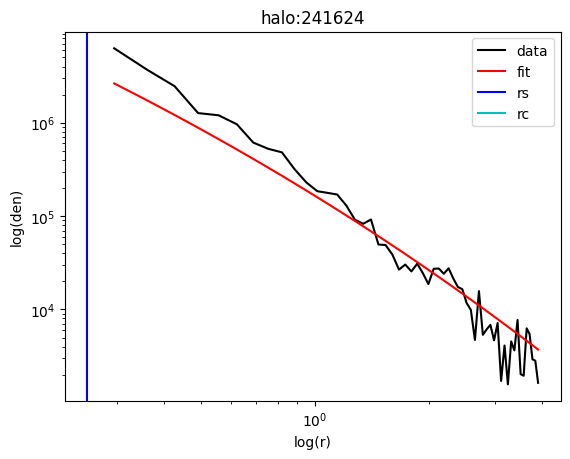

rc_i:0.0 rs_i: 0.25
  current ID: 241625
ID:241625 Mvir = 7.453e+06
rc_i:0.0 rs_i: 0.597
ID:241626 Mvir = 7.440e+06
rc_i:0.0 rs_i: 0.25
ID:241627 Mvir = 7.420e+06
rc_i:0.0 rs_i: 0.25
ID:241628 Mvir = 7.380e+06
rc_i:0.0 rs_i: 0.25
ID:241629 Mvir = 7.367e+06
rc_i:0.0 rs_i: 0.25
ID:241630 Mvir = 7.354e+06
rc_i:0.0 rs_i: 0.25
ID:241631 Mvir = 7.354e+06


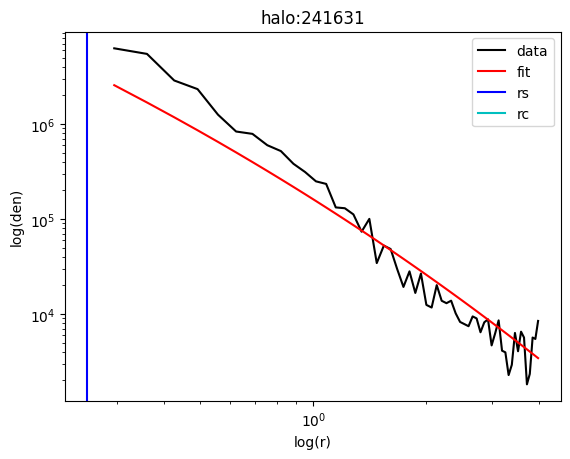

rc_i:0.0 rs_i: 0.25
ID:241632 Mvir = 7.340e+06
rc_i:0.0 rs_i: 0.25
ID:241633 Mvir = 7.300e+06
rc_i:0.0 rs_i: 0.257
ID:241634 Mvir = 7.294e+06
rc_i:0.0 rs_i: 0.25
ID:241635 Mvir = 7.294e+06
rc_i:0.0 rs_i: 0.25
ID:241636 Mvir = 7.287e+06
rc_i:0.0 rs_i: 0.25
ID:241637 Mvir = 7.260e+06
rc_i:0.0 rs_i: 0.269
ID:241638 Mvir = 7.254e+06
rc_i:0.0 rs_i: 0.25
ID:241639 Mvir = 7.240e+06
rc_i:0.0 rs_i: 0.384
ID:241640 Mvir = 7.227e+06
rc_i:0.0 rs_i: 0.304
ID:241641 Mvir = 7.207e+06
rc_i:0.0 rs_i: 0.25
ID:241642 Mvir = 7.194e+06
rc_i:0.0 rs_i: 0.25
ID:241643 Mvir = 7.180e+06
rc_i:0.0 rs_i: 0.25
ID:241644 Mvir = 7.180e+06
rc_i:0.0 rs_i: 0.25
ID:241645 Mvir = 7.174e+06
rc_i:0.0 rs_i: 0.525
ID:241646 Mvir = 7.167e+06
rc_i:0.0 rs_i: 0.25
ID:241647 Mvir = 7.160e+06
rc_i:0.0 rs_i: 0.278
ID:241648 Mvir = 7.154e+06
rc_i:0.0 rs_i: 0.25
ID:241649 Mvir = 7.120e+06
rc_i:0.0 rs_i: 0.273
  current ID: 241650
ID:241650 Mvir = 7.114e+06
rc_i:0.0 rs_i: 0.25
ID:241651 Mvir = 7.114e+06
rc_i:0.0 rs_i: 0.25
ID:241652 Mv

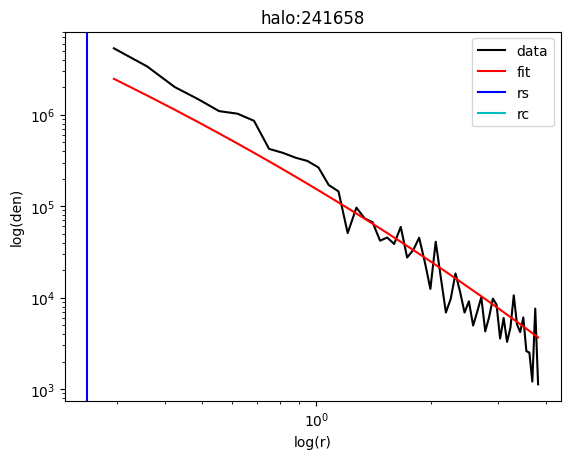

rc_i:0.0 rs_i: 0.25
ID:241659 Mvir = 7.034e+06
rc_i:0.0 rs_i: 0.25
ID:241660 Mvir = 7.000e+06
rc_i:0.0 rs_i: 0.25
ID:241661 Mvir = 6.994e+06
rc_i:0.0 rs_i: 0.277
ID:241662 Mvir = 6.994e+06


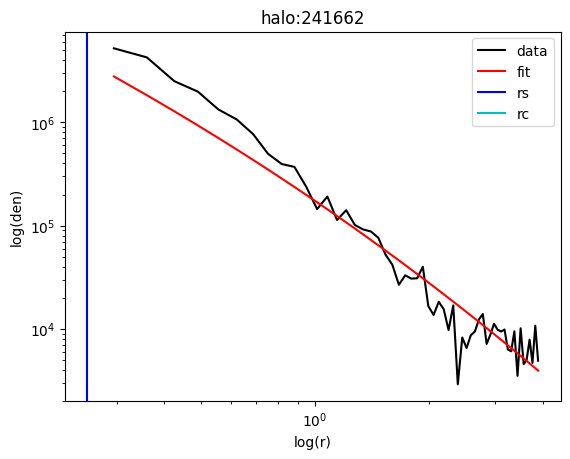

rc_i:0.0 rs_i: 0.25
ID:241663 Mvir = 6.994e+06
rc_i:0.0 rs_i: 0.25
ID:241664 Mvir = 6.994e+06
rc_i:0.0 rs_i: 0.25
ID:241665 Mvir = 6.981e+06
rc_i:0.0 rs_i: 0.25
ID:241666 Mvir = 6.974e+06
rc_i:0.0 rs_i: 0.277
ID:241667 Mvir = 6.967e+06
rc_i:0.0 rs_i: 0.25
ID:241668 Mvir = 6.967e+06
rc_i:0.0 rs_i: 0.25
ID:241669 Mvir = 6.967e+06
rc_i:0.0 rs_i: 0.25
ID:241670 Mvir = 6.914e+06
rc_i:0.0 rs_i: 0.25
ID:241671 Mvir = 6.901e+06
rc_i:0.0 rs_i: 0.476
ID:241672 Mvir = 6.894e+06
rc_i:0.0 rs_i: 0.311
ID:241673 Mvir = 6.874e+06


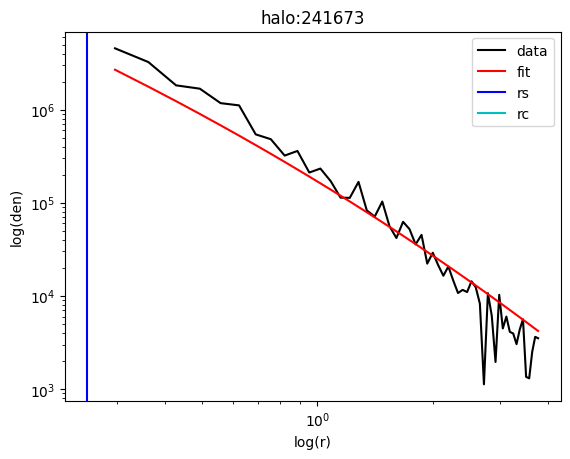

rc_i:0.0 rs_i: 0.25
ID:241674 Mvir = 6.861e+06
rc_i:0.0 rs_i: 0.25
  current ID: 241675
ID:241675 Mvir = 6.847e+06
rc_i:0.0 rs_i: 0.25
ID:241676 Mvir = 6.847e+06
rc_i:0.0 rs_i: 0.26
ID:241677 Mvir = 6.841e+06
rc_i:0.0 rs_i: 0.25
ID:241678 Mvir = 6.841e+06


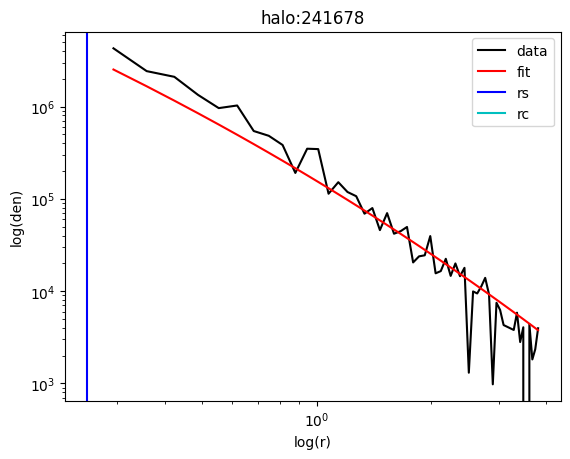

rc_i:0.0 rs_i: 0.25
ID:241679 Mvir = 6.821e+06


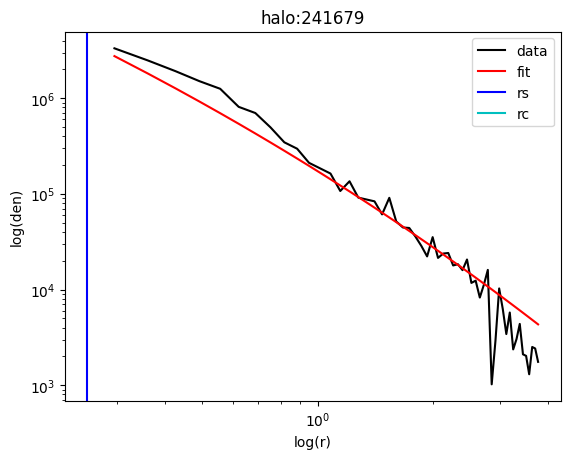

rc_i:0.0 rs_i: 0.25
ID:241680 Mvir = 6.774e+06
rc_i:0.0 rs_i: 0.323
ID:241681 Mvir = 6.774e+06
rc_i:0.0 rs_i: 0.25
ID:241682 Mvir = 6.754e+06


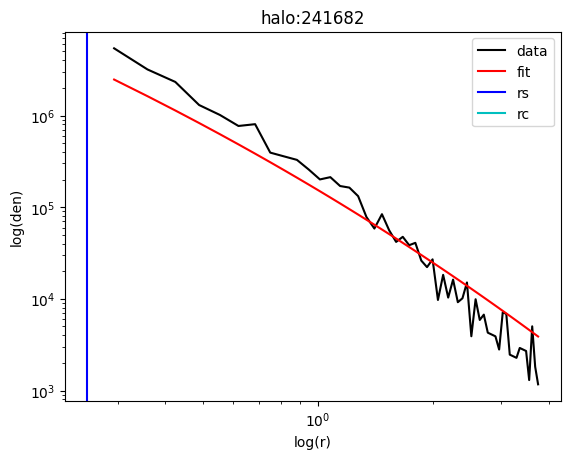

rc_i:0.0 rs_i: 0.25
ID:241683 Mvir = 6.741e+06
rc_i:0.0 rs_i: 0.255
ID:241684 Mvir = 6.727e+06
rc_i:0.0 rs_i: 0.25
ID:241685 Mvir = 7.237e+06
rc_i:0.0 rs_i: 0.28
ID:241686 Mvir = 6.721e+06
rc_i:0.0 rs_i: 0.257
ID:241687 Mvir = 6.707e+06
rc_i:0.0 rs_i: 0.25
ID:241688 Mvir = 6.701e+06


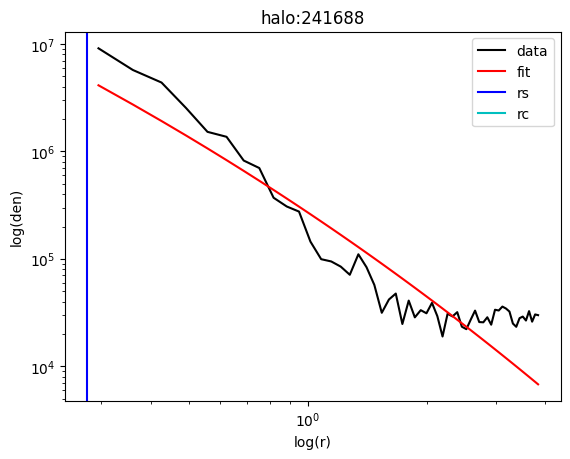

rc_i:0.0 rs_i: 0.276
ID:241689 Mvir = 6.701e+06
rc_i:0.0 rs_i: 0.25
ID:241690 Mvir = 6.681e+06


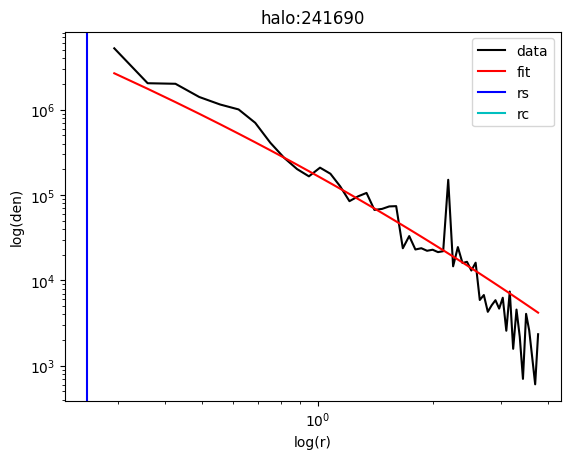

rc_i:0.0 rs_i: 0.25
 -----------------------> Q_sim = 0.099
number bad fits = 36
run time optim_fit =    82.10125263700002


In [2]:
# Anna code modified (run vbounds sims and create data) - basic
#======================================================================================================

# load sim
sim = tangos.all_simulations()[0]
sim_name = sim.basename

# constants
output = '004096'
fit_type = 'cEinasto'
baryon = False
family = 'dm'
model = 'SIDM'

halos = sim.timesteps[-1].halos
n_sim = halos.count()
print(f'length sim = {n_sim}')

# start of main program 
start = timeit.default_timer()

Q_avg = []
n_plt = 0

for halo in halos:

    HID = halo.id
    
    if int(HID) % 25 == 0:
        print(f'  current ID: {HID}')
    
    if 'dm_density_profile' in halo.keys():
        
        den = halo['dm_density_profile']
        rvir = halo["max_radius"]
        rs_bounds = np.linspace(0.25, rvir/5, 10)
     
        # find step size
        dr = rvir / len(den)

        # create r array (make bin edges then subtract dr/2 to get centers)
        r = np.linspace(dr , len(den)*dr, len(den)) - (dr/2)

        optim_fit(model, fit_type, output, rs_bounds, baryon, family, HID, r, den, rvir, sim_name)
        print(f"ID:{HID} Mvir = {halo['Mvir']:.3e}")
        
        fits = f"cvir_outputs/fits_output_sim_{sim_name}_ID_{HID}.txt"

        fit_df = pd.read_table(fits, sep=r'\s+')

        # find best fit 
        Q_vals = fit_df['Q'].to_numpy()
        min_ind = np.argmin(Q_vals)

        # get best fit params 
        rs   = fit_df['rs[kpc]'].to_numpy()
        rhos = fit_df['rhos'].to_numpy()
        rc   = fit_df['rc[kpc]'].to_numpy()
        rs_i = float(rs[min_ind])
        rhos_i = float(rhos[min_ind])
        rc_i = float(rc[min_ind])

        Q_avg_i = np.min(Q_vals)
        Q_avg.append(Q_avg_i)
        #print(f"ID {HID}: Q = {Q_avg_i:.4f}")


        if Q_avg_i > 0.2:
                
            # check fit 
            mask = (r >= 0.25) & (r <= rvir)
            r = r[mask]
            den = den[mask]
            rc = max(rc_i, 1e-8)
                
            fit = cEinasto_profile(r, rhos_i, rs_i, rc_i)
            
            plt.figure()
            plt.loglog(r, den, 'k', label = 'data')
            plt.loglog(r, fit, 'r', label = 'fit')
            plt.axvline(x=rs_i, color='b', label = 'rs')
            plt.axvline(x=rc_i, color='c', label = 'rc')
            plt.title(f'halo:{HID}')
            plt.xlabel('log(r)')
            plt.ylabel('log(den)')
            plt.legend()
            plt.show()

            n_plt += 1

        print(f'rc_i:{rc_i} rs_i: {rs_i}')

    else:
        print(f'halo:{HID} no dm profile. Mvir = {Mvir}')
        continue 

Q_sim = np.median(Q_avg)
stop = timeit.default_timer()
run_time = stop - start

print(f' -----------------------> Q_sim = {Q_sim}')
print(f'number bad fits = {n_plt}')
print('run time optim_fit =   ',run_time)


In [3]:
# Anna code modified (read data table + find cvir + write in sim specific output file) only Qmin

# constants
output = '004096'
fit_type = 'cEinasto'
baryon = False
family = 'dm'
model = 'SIDM'
db = 'Marvel'

n_sim = 4
error_file = f'cvir_results/cvir_logs_error_{db}.txt'
ferr = open(error_file, 'w')
ferr.write(f'Error log DB:{db}\n')

# Arrays for plotting
Mvir_all = []
cvir_all = []

for sim_id in range(n_sim):
    Nan_count = 0
    sim = tangos.all_simulations()[sim_id]
    sim_name = sim.basename
    
    halos = sim.timesteps[-1].halos
    halo_ids = np.array([str(h.id) for h in halos])
    Mvir_array = np.array([h['Mvir'] for h in halos])
    
    print(f"\nProcessing sim {sim_id}: {sim}")

    # Open the output file for writing
    out_file = f'cvir_results/cvir_logs_{sim_name}.txt'
    f = open(out_file, 'w')
    f.write('halos\tcvir\tQ min\tMvir\n')

    for ID_index, HID in enumerate(halo_ids):
            
        filepath = f"cvir_outputs/logs_output_sim_{sim_name}_ID_{HID}.txt"
        if not os.path.exists(filepath):
            f.write(f'{HID}\t{"NaN"}\t{"NaN"}\t{Mvir_array[ID_index]}\n')
            Nan_count += 1
            continue
            

        fit_df = pd.read_table(filepath, sep=r'\s+')

        Q    = fit_df['Q'].to_numpy()
        rs   = fit_df['rs[kpc]'].to_numpy()
        rc   = fit_df['rc[kpc]'].to_numpy()
        rvir = fit_df['rvir[kpc]'].to_numpy()
        rhos = fit_df['rhos'].to_numpy()

        min_ind = np.argmin(Q)
        Q_min = float(Q[min_ind])

        if Q_min > 0.2:
            print(f'Error ID:{HID}\tMvir = {Mvir_array[ID_index]:.3e}  High Q value Q={Q_min}', file=ferr)
            f.write(f'{HID}\t{"NaN"}\t{"NaN"}\t{Mvir_array[ID_index]}\n')
            Nan_count += 1
            continue 

        rs_i = float(rs[min_ind])
        rc_i = float(rc[min_ind])

        if rc_i > rs_i:
            print(f'Error ID:{HID}\tMvir = {Mvir_array[ID_index]:.3e}  rc > rs', file=ferr)
            f.write(f'{HID}\t{"NaN"}\t{"NaN"}\t{Mvir_array[ID_index]}\n')
            Nan_count += 1
            continue 

        if rs_i < 0.25:
            print(f'Error ID:{HID}\tMvir = {Mvir_array[ID_index]:.3e}  rs too small rs = {rs_i}', file=ferr) 
            f.write(f'{HID}\t{"NaN"}\t{"NaN"}\t{Mvir_array[ID_index]}\n')
            Nan_count += 1
            continue 
            
        rho_i = float(rhos[min_ind])
        r200_i = rvir[min_ind]

        r = np.linspace(0.25, r200_i, 100)
        m2_slope = cEinasto_logslope(r, rs_i, rc_i) + 2
        m2_slope_ind = np.argmin(np.abs(m2_slope))
        r2 = r[m2_slope_ind]

        cvir = r200_i / r2
        f.write(f'{HID}\t{cvir}\t{Q_min}\t{Mvir_array[ID_index]}\n')


    print(f'sim {sim_name} contains {Nan_count} NaN values / {len(halo_ids)}\n\n', file=ferr)
    



Processing sim 0: <Simulation("cptmarvel.cosmo25cmb.4096g5HbwK1BH")>

Processing sim 1: <Simulation("elektra.cosmo25cmb.4096g5HbwK1BH")>

Processing sim 2: <Simulation("rogue.cosmo25cmb.4096g5HbwK1BH")>

Processing sim 3: <Simulation("storm.cosmo25cmb.4096g5HbwK1BH")>


In [17]:

sim = tangos.all_simulations()[3]
sim_name = sim.basename

halos = sim.timesteps[-1].halos
halo_ids = [str(h.finder_id) for h in halos]
halos[300].finder_id

438